In [1]:
from pathlib import Path
import sys
import importlib
import numpy as np
import matplotlib.pyplot as plt

# Import from either the repository root or the Analysis folder.
analysis_dir = Path.cwd() if Path("Experimental_Import.py").exists() else Path.cwd() / "Analysis"
sys.path.insert(0, str(analysis_dir))
import Experimental_Import as module
importlib.reload(module)
from Experimental_Import import Experimental_Import
from matplotlib.colors import LinearSegmentedColormap


In [2]:
file_path = Path(
    "/Users/yiyangzhi/Library/CloudStorage/"
    "GoogleDrive-yiyang_zhi3@berkeley.edu/My Drive/"
    "Ming Wu Integrated Photonics Group/Experiments/Measurements/"
    "Barium_90um_unknown/"
)

wl_arr = ['450_nm', '515_nm', '635_nm']
pol_arr = ['TE', 'TM']
white_img_name = 'white_light.tiff'

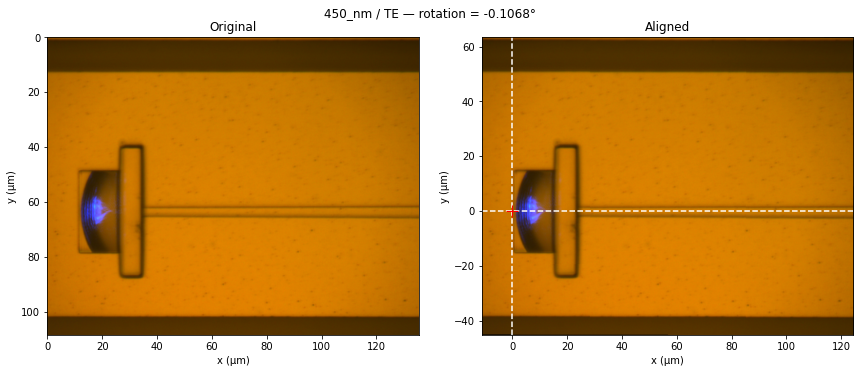

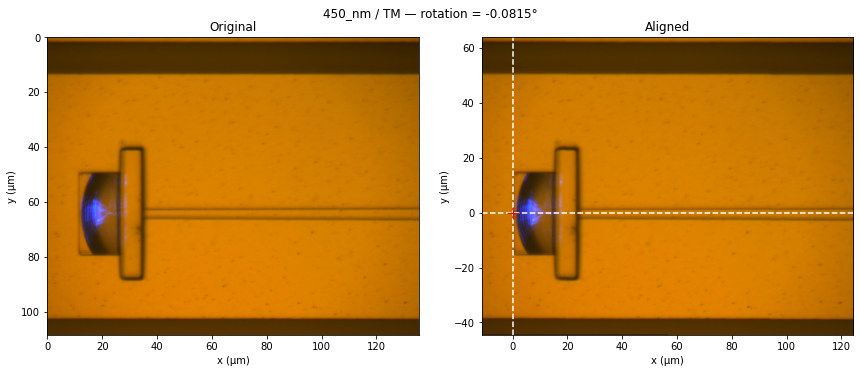

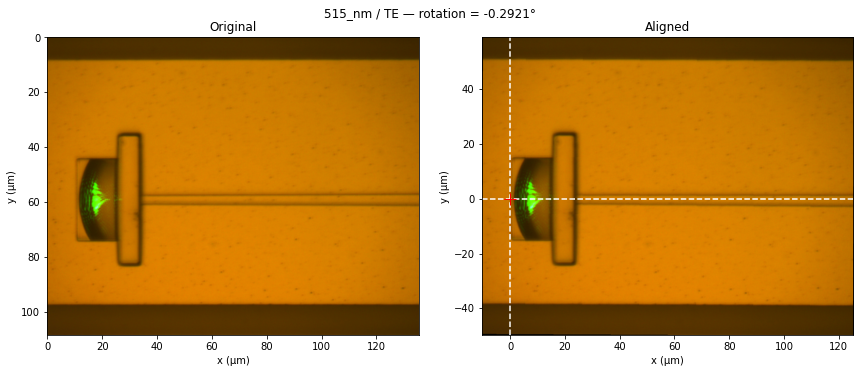

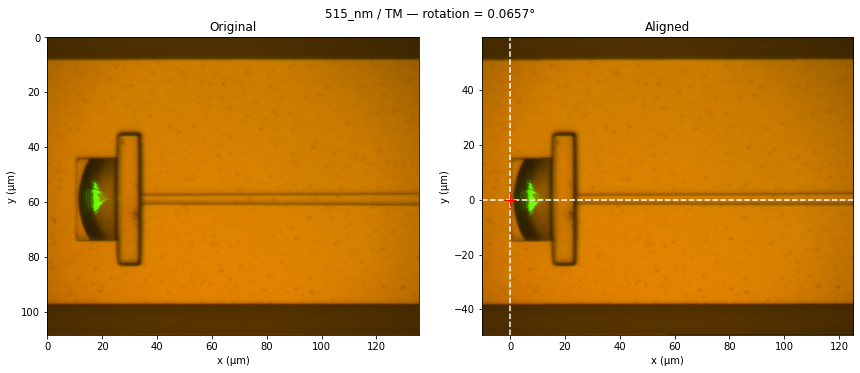

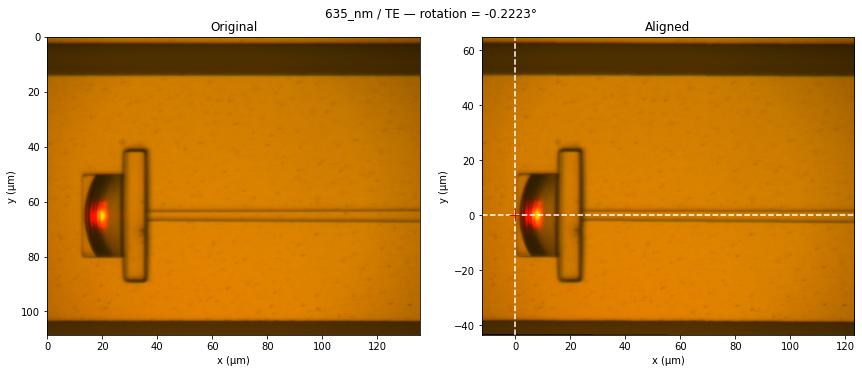

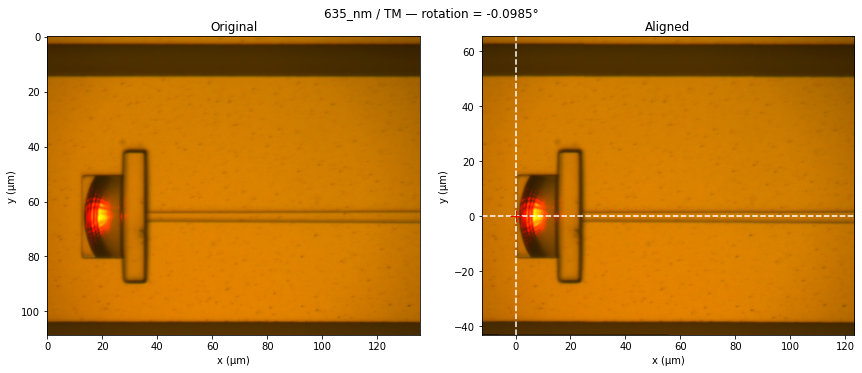

In [3]:
experiment = Experimental_Import(pixel_size_um=5.3, magnification=50)
alignments = {}

for wl in wl_arr:
    alignments[wl] = {}

    for pol in pol_arr:
        white_path = file_path / wl / pol / white_img_name

        x, y, image, angle, x_old, y_old, image_old = (
            experiment.align_cache_zone(white_path)
        )

        alignments[wl][pol] = {
            "x": x, "y": y, "image": image, "angle": angle,
            "x_old": x_old, "y_old": y_old, "image_old": image_old,
        }

        fig, axes = plt.subplots(
            1, 2, figsize=(12, 5), constrained_layout=True
        )

        for ax, xx, yy, img, title in [
            (axes[0], x_old, y_old, image_old, "Original"),
            (axes[1], x, y, image, "Aligned"),
        ]:
            dx = xx[1] - xx[0]
            dy = yy[1] - yy[0]
            extent = [
                xx[0] - dx/2, xx[-1] + dx/2,
                yy[-1] + dy/2, yy[0] - dy/2,
            ]

            ax.imshow(img, origin="upper", extent=extent, cmap="gray")
            ax.set(title=title, xlabel="x (µm)", ylabel="y (µm)")

        axes[1].axvline(0, color="white", linestyle="--")
        axes[1].axhline(0, color="white", linestyle="--")
        axes[1].plot(0, 0, "r+", markersize=12)

        fig.suptitle(f"{wl} / {pol} — rotation = {angle:.4f}°")
        plt.show()
        plt.close(fig)

In [4]:
height_scans = {}

for wl in wl_arr:
    height_scans[wl] = {}

    for pol in pol_arr:
        scan_folder = file_path / wl / pol / "height_scan"
        angle = alignments[wl][pol]["angle"]

        height_um, intensity, exposure_ms = experiment.import_height_scan(
            scan_folder,
            angle,
            height_spacing_um=1.0,
        )

        # intensity = experiment.subtract_background(intensity, exposure_ms)

        height_scans[wl][pol] = {
            "height_um": height_um,
            "intensity": intensity,
            "exposure_ms": exposure_ms,
        }

        print(f"{wl} / {pol}")
        print(f"  Imported {len(height_um)} images; shape: {intensity.shape}")
        print(f"  Heights: {height_um[0]:g} to {height_um[-1]:g} µm")


450_nm / TE
  Imported 150 images; shape: (150, 1024, 1280)
  Heights: 1 to 150 µm
450_nm / TM
  Imported 150 images; shape: (150, 1024, 1280)
  Heights: 1 to 150 µm
515_nm / TE
  Imported 150 images; shape: (150, 1024, 1280)
  Heights: 1 to 150 µm
515_nm / TM
  Imported 150 images; shape: (150, 1024, 1280)
  Heights: 1 to 150 µm
635_nm / TE
  Imported 150 images; shape: (150, 1024, 1280)
  Heights: 1 to 150 µm
635_nm / TM
  Imported 150 images; shape: (150, 1024, 1280)
  Heights: 1 to 150 µm


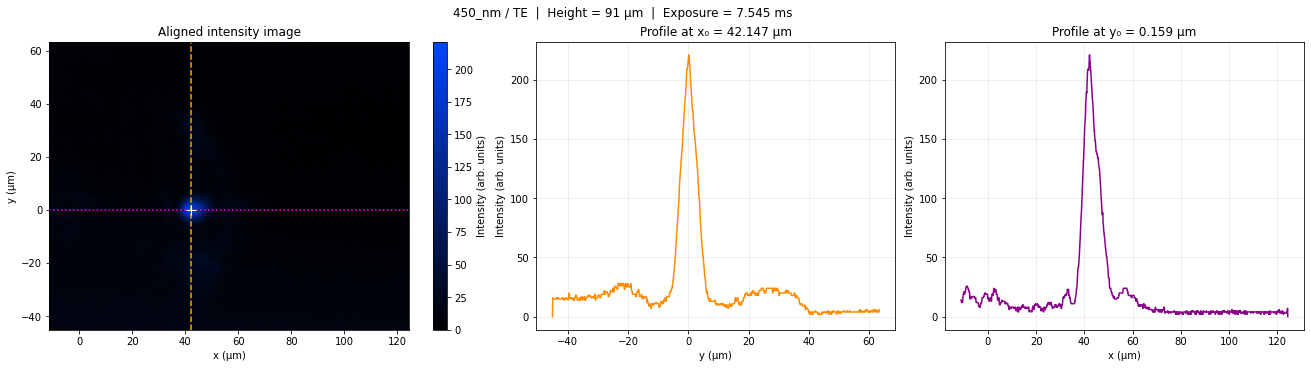

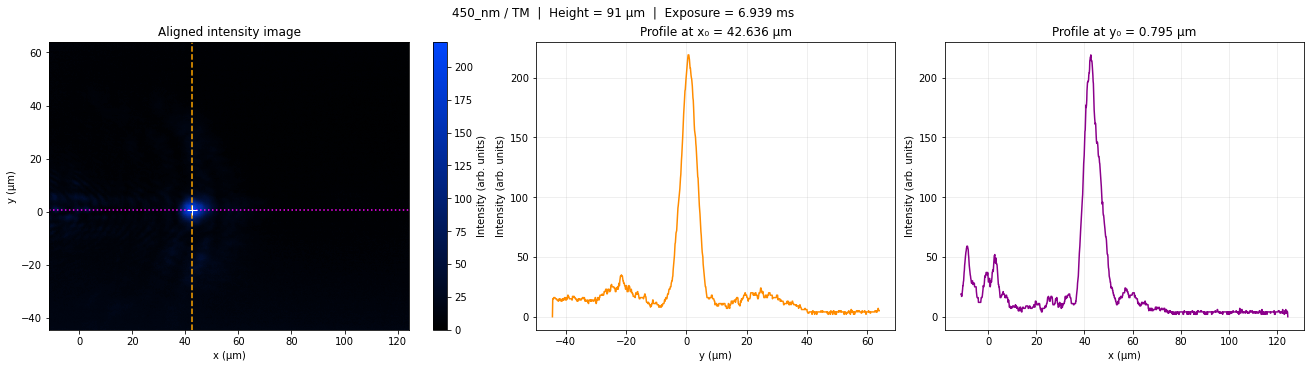

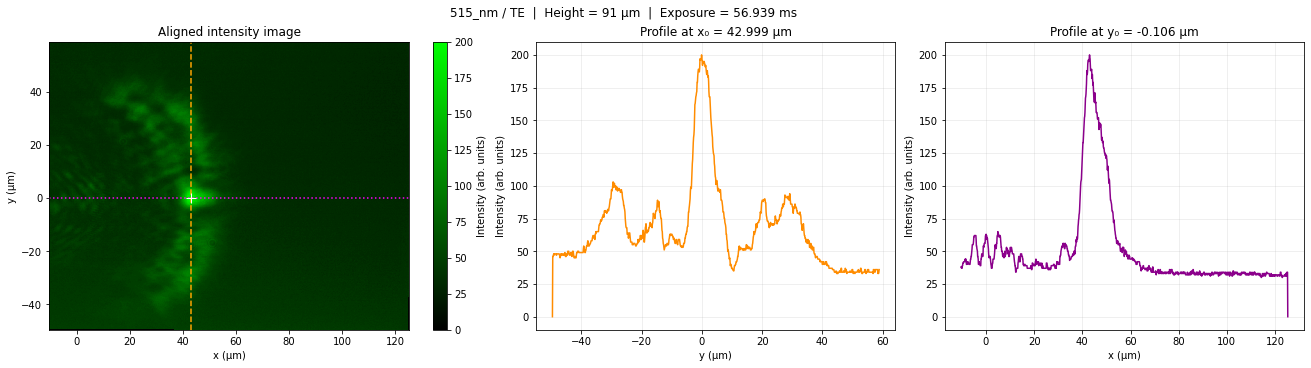

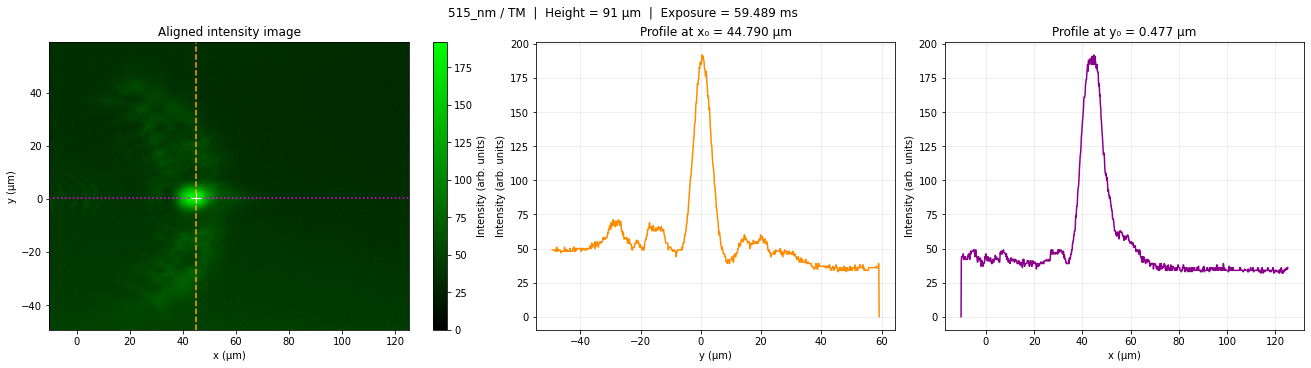

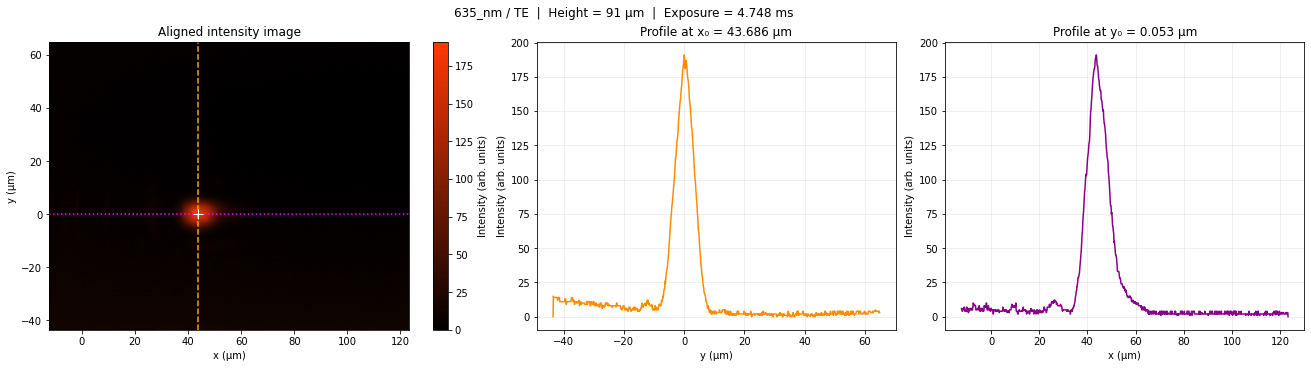

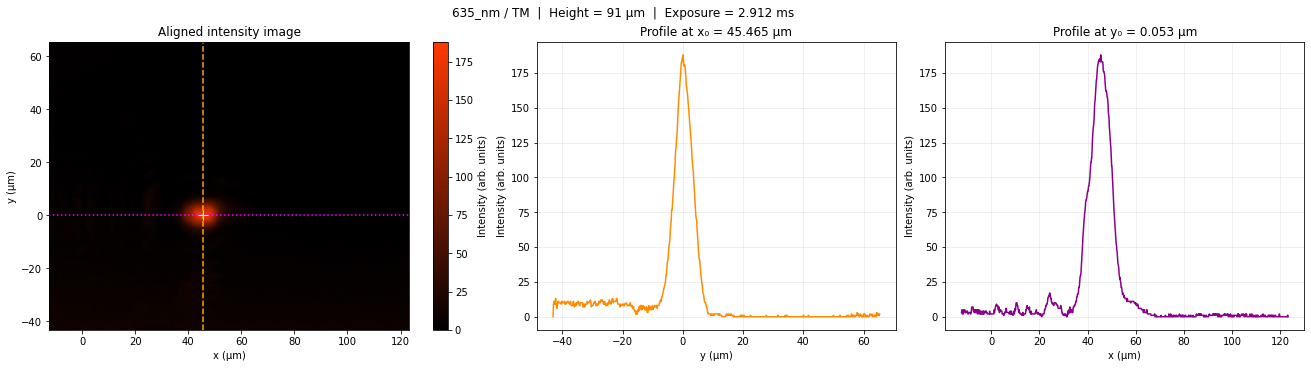

In [5]:
height_to_plot_um = 91
colors = {
    "450_nm": "#0046ff",
    "515_nm": "#00ff00",
    "635_nm": "#ff3900",
}

for wl in wl_arr:
    for pol in pol_arr:
        # Get this pair's scan and aligned coordinates.
        scan = height_scans[wl][pol]
        x = alignments[wl][pol]["x"]
        y = alignments[wl][pol]["y"]

        height_um = scan["height_um"]
        exposure_ms = scan["exposure_ms"]

        # Select the nearest height.
        frame_index = np.argmin(np.abs(height_um - height_to_plot_um))
        frame = scan["intensity"][frame_index]

        # Locate the maximum within this image.
        row, column = np.unravel_index(np.argmax(frame), frame.shape)
        x0, y0 = x[column], y[row]

        cmap = LinearSegmentedColormap.from_list(
            wl, ["black", colors[wl]]
        )

        fig, axes = plt.subplots(
            1, 3,
            figsize=(19, 5),
            constrained_layout=True,
            gridspec_kw={"width_ratios": [1.3, 1, 1]},
        )

        # Panel 1: image with both slices marked through the maximum.
        view = axes[0].pcolormesh(
            x, y, frame,
            shading="nearest", cmap=cmap, vmin=0,
        )
        axes[0].axvline(x0, color="orange", linestyle="--")
        axes[0].axhline(y0, color="magenta", linestyle=":")
        axes[0].plot(x0, y0, "w+", markersize=10)
        axes[0].set(
            title="Aligned intensity image",
            xlabel="x (µm)", ylabel="y (µm)",
            aspect="equal",
        )
        fig.colorbar(view, ax=axes[0], label="Intensity (arb. units)")

        # Panel 2: vary y while holding x at the maximum's x coordinate.
        axes[1].plot(y, frame[:, column], color="darkorange")
        axes[1].set(
            title=f"Profile at x₀ = {x0:.3f} µm",
            xlabel="y (µm)", ylabel="Intensity (arb. units)",
        )
        axes[1].grid(alpha=0.25)

        # Panel 3: vary x while holding y at the maximum's y coordinate.
        axes[2].plot(x, frame[row, :], color="darkmagenta")
        axes[2].set(
            title=f"Profile at y₀ = {y0:.3f} µm",
            xlabel="x (µm)", ylabel="Intensity (arb. units)",
        )
        axes[2].grid(alpha=0.25)

        fig.suptitle(
            f"{wl} / {pol}  |  "
            f"Height = {height_um[frame_index]:g} µm  |  "
            f"Exposure = {exposure_ms[frame_index]:.3f} ms"
        )

        plt.show()
        plt.close(fig)

In [6]:
for wl in wl_arr:
    for pol in pol_arr:
        scan = height_scans[wl][pol]
        alignment = alignments[wl][pol]

        save_path = file_path / wl / pol / "height_scan.npz"

        np.savez_compressed(
            save_path,
            height_um=scan["height_um"],
            intensity=scan["intensity"],
            exposure_ms=scan["exposure_ms"],
            x_um=alignment["x"],
            y_um=alignment["y"],
            angle_deg=alignment["angle"],
        )

        print(f"Saved: {save_path}")

Saved: /Users/yiyangzhi/Library/CloudStorage/GoogleDrive-yiyang_zhi3@berkeley.edu/My Drive/Ming Wu Integrated Photonics Group/Experiments/Measurements/Barium_90um_unknown/450_nm/TE/height_scan.npz
Saved: /Users/yiyangzhi/Library/CloudStorage/GoogleDrive-yiyang_zhi3@berkeley.edu/My Drive/Ming Wu Integrated Photonics Group/Experiments/Measurements/Barium_90um_unknown/450_nm/TM/height_scan.npz
Saved: /Users/yiyangzhi/Library/CloudStorage/GoogleDrive-yiyang_zhi3@berkeley.edu/My Drive/Ming Wu Integrated Photonics Group/Experiments/Measurements/Barium_90um_unknown/515_nm/TE/height_scan.npz
Saved: /Users/yiyangzhi/Library/CloudStorage/GoogleDrive-yiyang_zhi3@berkeley.edu/My Drive/Ming Wu Integrated Photonics Group/Experiments/Measurements/Barium_90um_unknown/515_nm/TM/height_scan.npz
Saved: /Users/yiyangzhi/Library/CloudStorage/GoogleDrive-yiyang_zhi3@berkeley.edu/My Drive/Ming Wu Integrated Photonics Group/Experiments/Measurements/Barium_90um_unknown/635_nm/TE/height_scan.npz
Saved: /Users/y